In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA

In [2]:
clin = pd.read_csv('clin_ready.csv', header = 0, index_col=0)
clin = clin.drop(labels = [1578], axis = 0)
prot = pd.read_csv('raw_data_proteins_filtered.csv',header = 0, index_col = 0)
prot_list = pd.read_csv('prot_filtered.csv', header = 0, index_col=0)

prot = prot.filter(prot_list.iloc[:,0], axis = 1)
prot = prot.drop(labels = [1578], axis = 0)

# scale data 
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(prot)
prot_scaled = scaler.transform(prot)
prot_scaled = pd.DataFrame(prot_scaled)
prot_scaled.index = prot.index
prot_scaled.columns = prot.columns
prot_scaled = prot_scaled.reindex(prot.index)

In [3]:
pca_df = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/PCA_24.csv', index_col=0) 
clin = clin.reindex(pca_df.index)
shap_df = pd.DataFrame(pca_df)
shap_df.index = pca_df.index

bottom_left = shap_df[(shap_df.iloc[:,0]<=0.05) & (shap_df.iloc[:,1]<0.03)]
bottom_right = shap_df[(shap_df.iloc[:,0]>=0.05) & (shap_df.iloc[:,1]<-0.05)]
bottom_right.shape

bottom = bottom_left.append(bottom_right)
bottom.shape

# top branch
top_index=[]
for i in shap_df.index:
    if i not in bottom.index:
        top_index.append(i)
top = shap_df.filter(items = top_index, axis = 0)

0.07228135880855549
0.02650183999164113
0.037414383240679194
0.011568506787160914


<AxesSubplot:>

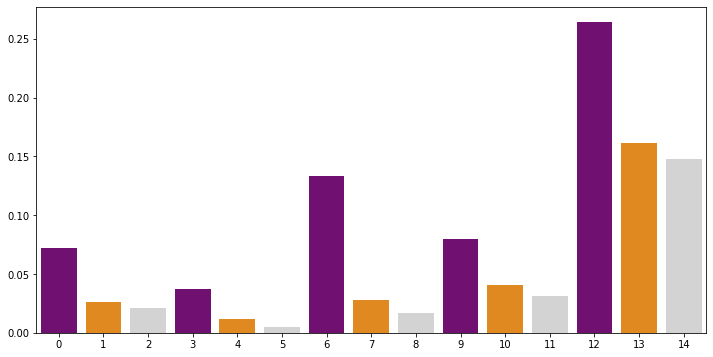

In [20]:
# filter based on top and bottom indices and check for tbi prot
palette = sns.color_palette(['purple','darkorange','lightgrey'])

top_ = prot_scaled.filter(items = top.index, axis = 0)
bottom_ = prot_scaled.filter(items = bottom.index, axis = 0)

# let's check for 
# markers of TBI intracranial bleeding
print(top_['UCHL1.5019.16'].mean())
print(bottom_['UCHL1.5019.16'].mean())

# markers of intracranial bleeding
print(top_['GFAP.3034.1'].mean())
print(bottom_['GFAP.3034.1'].mean())

bottom_clin = clin.filter(items = bottom.index, axis =0)
ctrl = bottom_clin[(bottom_clin['iss']<4) & (bottom_clin['admission_gcs']>12)]
ctrl_data = prot_scaled.filter(items = ctrl.index, axis =0)
ctrl_data['UCHL1.5019.16'].mean()

plt.figure(figsize = (12, 6))
sns.barplot(x = [0,1,2,3,4,5,6,7,8,9,10,11, 12, 13, 14], y =[top_['UCHL1.5019.16'].mean(), bottom_['UCHL1.5019.16'].mean(),
                                   ctrl_data['UCHL1.5019.16'].mean(),top_['GFAP.3034.1'].mean(),
                                   bottom_['GFAP.3034.1'].mean(), ctrl_data['GFAP.3034.1'].mean(),
                                   top_['MAPT.5854.60'].mean(), bottom_['MAPT.5854.60'].mean(),
                                   ctrl_data['MAPT.5854.60'].mean(),top_['NEFL.10082.251'].mean(), 
                                   bottom_['NEFL.10082.251'].mean(), ctrl_data['NEFL.10082.251'].mean(),
                                   top_['ENO2.10339.48'].mean(), bottom_['ENO2.10339.48'].mean(), 
                                   ctrl_data['ENO2.10339.48'].mean()], palette = palette)


In [217]:
# to separate males and females
# m = clin[clin['sex']=='Male'].index
# f = clin[clin['sex']=='Female'].index

# top_ = top_.filter(items = f, axis = 0)
# bottom_ = bottom_.filter(items = f, axis = 0)


In [5]:
# just plot the folds because it's better and we solve the problem of the scale
proteins = ['UCHL1.5019.16', 'GFAP.3034.1', 'MAPT.5854.60', 'NEFL.10082.251', 'ENO2.10339.48']

expr_A=[]
expr_B=[]
expr_Ctr=[]
for prot in proteins:
    expr_A.append(bottom_[prot].mean())
    expr_B.append(top_[prot].mean())
    expr_Ctr.append(ctrl_data[prot].mean())
    
    
ratios_df = pd.DataFrame(expr_A)
ratios_df['expr_B'] = expr_B
ratios_df['expr_Ctr'] = expr_Ctr
ratios_df.columns = ['expr_A', 'expr_B', 'expr_Ctr']

ratios_df['ratioA'] = ratios_df['expr_A']/ratios_df['expr_Ctr']-1
ratios_df['ratioB'] = ratios_df['expr_B']/ratios_df['expr_Ctr']-1

In [6]:
ratios_df.index = proteins

# join the two lists and then join the labels
final_data = ratios_df['ratioA'].append(ratios_df['ratioB'])
final_labels = ratios_df.index.append(ratios_df.index)

df_da_usare = pd.DataFrame(final_data)
df_da_usare['final_labels'] = [i.split(".")[0] for i in final_labels]
df_da_usare.columns = ['final_data', 'final_labels']
df_da_usare['type'] = ['Fold change A']*5 + ['Fold change B']*5


<AxesSubplot:title={'center':'foldchange from controls'}, xlabel='final_labels', ylabel='final_data'>

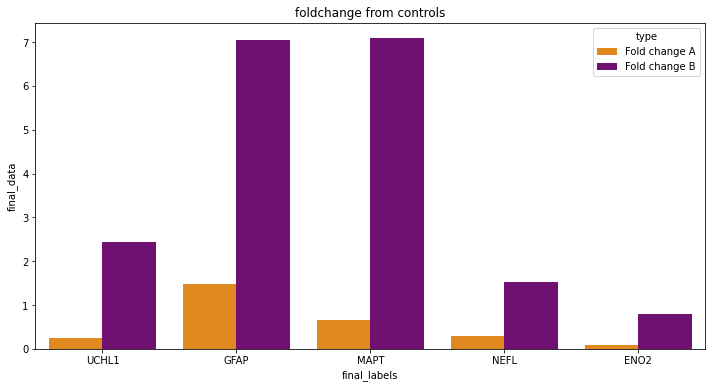

In [7]:
plt.figure(figsize = (12, 6))
plt.title("foldchange from controls")
sns.barplot(x = 'final_labels', y = 'final_data', data = df_da_usare, hue = 'type', palette = palette)

In [8]:
clin.filter(items = top_.index, axis = 0)['sex'].value_counts()

Male      116
Female     27
Name: sex, dtype: int64

In [9]:
clin.filter(items = bottom_.index, axis = 0)['age'].mean()

40.96309963099631

### ONLY ISS >15

In [16]:
### ONly look at patients above 15

top_15 = top_.filter(items= clin[clin['iss']>=15].index, axis = 0)
bottom_15 = bottom_.filter(items= clin[clin['iss']>=15].index, axis = 0)
print(len(top_15))
print(len(bottom_15))

121
64


<AxesSubplot:title={'center':'foldchange from controls'}, xlabel='final_labels', ylabel='final_data'>

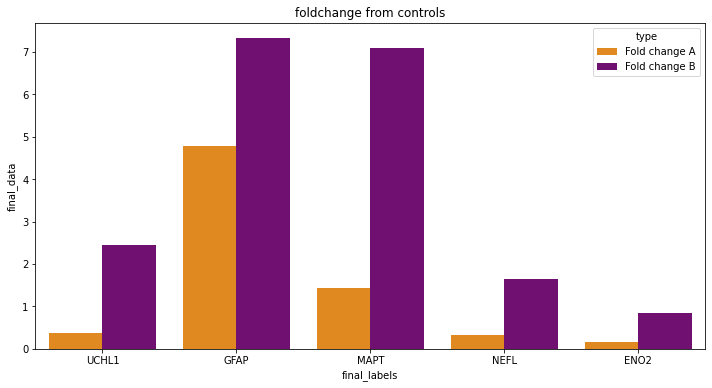

In [18]:
expr_A=[]
expr_B=[]
expr_Ctr=[]
for prot in proteins:
    expr_A.append(bottom_15[prot].mean())
    expr_B.append(top_15[prot].mean())
    expr_Ctr.append(ctrl_data[prot].mean())
    
    
ratios_df = pd.DataFrame(expr_A)
ratios_df['expr_B'] = expr_B
ratios_df['expr_Ctr'] = expr_Ctr
ratios_df.columns = ['expr_A', 'expr_B', 'expr_Ctr']

ratios_df['ratioA'] = ratios_df['expr_A']/ratios_df['expr_Ctr']-1
ratios_df['ratioB'] = ratios_df['expr_B']/ratios_df['expr_Ctr']-1

ratios_df.index = proteins

# join the two lists and then join the labels
final_data = ratios_df['ratioA'].append(ratios_df['ratioB'])
final_labels = ratios_df.index.append(ratios_df.index)

df_da_usare = pd.DataFrame(final_data)
df_da_usare['final_labels'] = [i.split(".")[0] for i in final_labels]
df_da_usare.columns = ['final_data', 'final_labels']
df_da_usare['type'] = ['Fold change A']*5 + ['Fold change B']*5

plt.figure(figsize = (12, 6))
plt.title("foldchange from controls")
sns.barplot(x = 'final_labels', y = 'final_data', data = df_da_usare, hue = 'type', palette = palette)

<AxesSubplot:>

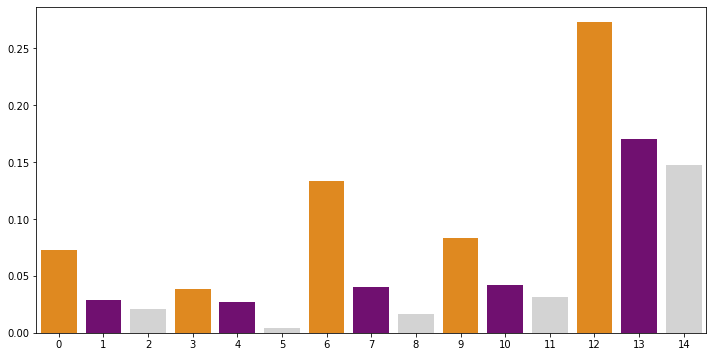

In [19]:
# actual expression in >15
plt.figure(figsize = (12, 6))
sns.barplot(x = [0,1,2,3,4,5,6,7,8,9,10,11, 12, 13, 14], y =[top_15['UCHL1.5019.16'].mean(), bottom_15['UCHL1.5019.16'].mean(),
                                   ctrl_data['UCHL1.5019.16'].mean(),top_15['GFAP.3034.1'].mean(),
                                   bottom_15['GFAP.3034.1'].mean(), ctrl_data['GFAP.3034.1'].mean(),
                                   top_15['MAPT.5854.60'].mean(), bottom_15['MAPT.5854.60'].mean(),
                                   ctrl_data['MAPT.5854.60'].mean(),top_15['NEFL.10082.251'].mean(), 
                                   bottom_15['NEFL.10082.251'].mean(), ctrl_data['NEFL.10082.251'].mean(),
                                   top_15['ENO2.10339.48'].mean(), bottom_15['ENO2.10339.48'].mean(), 
                                   ctrl_data['ENO2.10339.48'].mean()], palette = palette)
